# Serpientes y escaleras y Problema del Ratón

Hernández Ramírez Frida Karol 

## Serpientes y escaleras 

In [8]:
!pip install numpy matplotlib sympy

mambajs 0.19.13

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.


In [9]:
import random
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

#### Definición del tablero

El tablero cuenta con 20 casillas, de las cuales no todas son iguales.

Las casillas especiales son:

- Escalera: 3 → 11
- Escalera: 15 → 19
- Serpiente: 13 → 4
- Serpiente: 17 → 9

In [10]:
# Diccionario que almacena las serpientes y escaleras
# El primer número representa la casilla donde cae el jugador y el segundo número representa la casilla a la que se moverá

especiales = {
    3:11,
    15:19,
    13:4,
    17:9 }

Las escaleras nos permiten avanzar saltando casillas en el tablero, mientras que las serpientes nos hacen retroceder.

Ahora construiremos una función que detectará las casillas especiales:

In [11]:
# Función que revisa si el jugador cayó en una serpiente o escalera

def mover(posicion):

    # Revisar si la casilla es especial
    if posicion in especiales:

        # Regresar la nueva posición
        return especiales[posicion]

    # Si no ocurre nada especial
    return posicion

#### Simulación de una partida

Ahora se simularemos una partida, en cada turno:

- Se lanza un dado.
- El jugador avanza.
- Se revisa si cayó en una serpiente o escalera.
- Se guarda el recorrido realizado.

In [12]:
# Posición inicial del jugador
posicion = 1

# Contador de tiradas
tiradas = 0

# Lista para guardar todo el recorrido
historial = [posicion]

# Continuamow mientras no lleguemos a la meta (20)
while posicion < 20:

    # Lanzamiento del dado
    dado = random.randint(1,6)

    # Avanzamos
    posicion += dado

    # Si la posición supera 20 se ajusta al final del tablero
    if posicion > 20:
        posicion = 20

    posicion = mover(posicion)

    # Guardamos la posición actual
    historial.append(posicion)
    
    tiradas += 1

print(f"Número total de tiradas: {tiradas}")
print(f"Recorrido realizado: {historial}")

Número total de tiradas: 8
Recorrido realizado: [1, 6, 8, 12, 14, 9, 14, 16, 20]


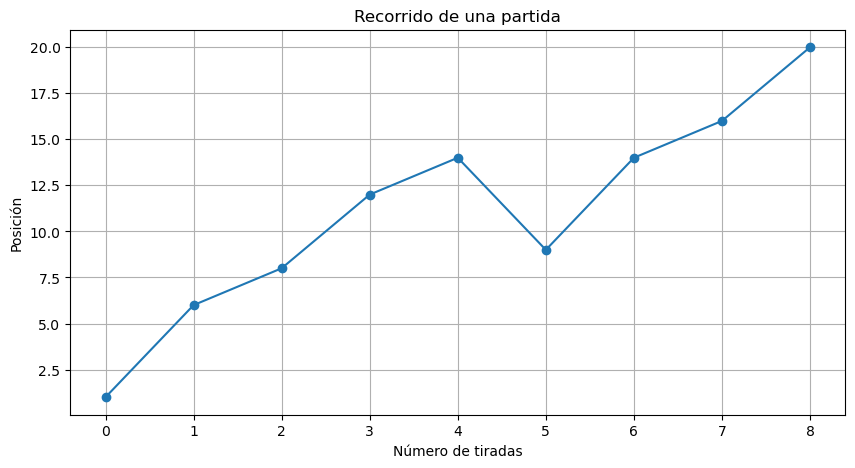

In [13]:
# Graficando el recorrido:

plt.figure(figsize=(10,5))

plt.plot(
    range(len(historial)),
    historial,
    marker = "o"
)

plt.title("Recorrido de una partida")

plt.xlabel("Número de tiradas")
plt.ylabel("Posición")

plt.grid()

plt.show()

Observamos que cuando subimos rápidamente corresponde a una escalera, en cambio, cuando retrocedemos de forma repentina corresponde a una serpiente.

#### Simulación de muchas partidas

Usando el método de Monte Carlo vamos a realizar simulaciones independientes para poder estimar realmente el comportamiento promedio de este juego.

In [14]:
def juego():

    # Posición inicial
    posicion = 1

    # Contador de tiradas
    tiradas = 0

    # Mientras no lleguemos a la meta
    while posicion < 20:

        # Lanzamiento del dado
        dado = random.randint(1,6)

        # Movimiento de casillas
        posicion += dado

        # Si superamos la casilla final
        if posicion > 20:
            posicion = 20

        posicion = mover(posicion)
            
        tiradas += 1

    # Regresamos el total de tiradas utilizadas
    return tiradas

#### Método Monte Carlo

El método Monte Carlo consiste en repetir un experimento aleatorio muchas veces para aproximar cantidades probabilísticas, en nuestro caso, se repetiremos el juego miles de veces para aproximar el número esperado de tiradas.

In [16]:
# Número total de simulaciones

N = 10000

# Lista para guardar resultados

resultados = []

# Ejecutando simulaciones

for i in range(N):

    resultado = juego()

    resultados.append(resultado)

# Calculando promedio

promedio = np.mean(resultados)

print(f"Promedio de tiradas: {promedio:.2f}")

Promedio de tiradas: 7.00


El promedio que obtuvimos representa una aproximación del número de tiradas qué son necesarias para terminar el juego.

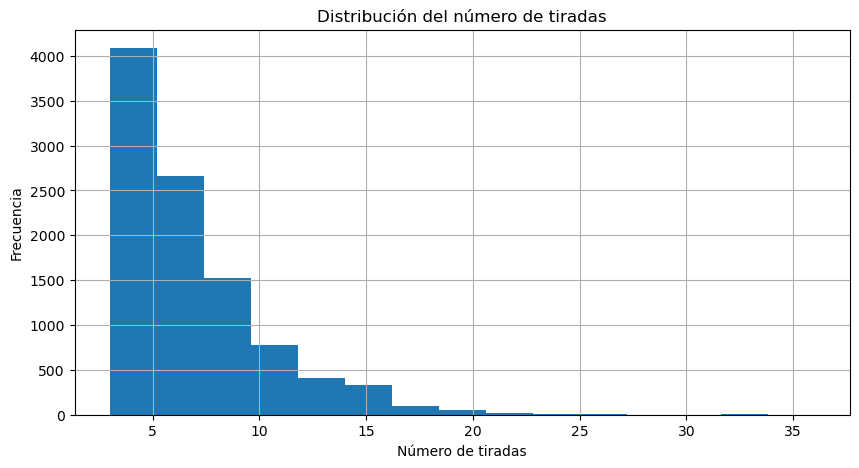

In [18]:
# Histograma:

plt.figure(figsize=(10,5))

plt.hist(
    resultados,
    bins = 15
)

plt.title("Distribución del número de tiradas")

plt.xlabel("Número de tiradas")
plt.ylabel("Frecuencia")

plt.grid()

plt.show()

Observamos que la mayor parte de las partidas terminan aproximadamente entre 4 y 10 tiradas.

Sea $E_i$ el número esperado de tiradas que necesitamos para llegar a la meta comenzando desde la casilla $i$

La casilla final corresponde a un estado absorbente: $E_{20}=0$ ,ya que una vez alcanzada la meta, terminamos el juego.

Para cualquier otra casilla: $E_i = 1 + \frac{1}{6}\sum_{k=1}^{6} E_{f(i+k)}$

La suma representa todas las posiciones posibles a las que podemos avanzar después de lanzar el dado.

La ecuación considera:

- la tirada actual,
- más el número esperado de tiradas restantes.

La función $f(i)$ representa las modificaciones provocadas por las serpientes y escaleras.

Por ejemplo:

- si el jugador cae en la casilla 3, automáticamente avanza a la 11,
- si cae en la casilla 13, retrocede a la 4.

#### Conclusiones

El juego lo podemos modelar con una cadena de Markov ya que el siguiente movimiento depende únicamente de la posición actual del jugador.

La simulación Monte Carlo nos permitió aproximar experimentalmente el número promedio de tiradas que necesitamos para terminar el juego.

Además las gráficas nos ayudaron a ver el comportamiento aleatorio del proceso y las consecuencias de las serpientes y escaleras.

## Laberinto

Tenemos que:

- El ratón inicia en la casilla 0.

- La comida se encuentra en la casilla 7.

- La descarga eléctrica se encuentra en la casilla 8.

- En cada paso el ratón elige aleatoriamente uno de los caminos disponibles.

Las conexiones entre casillas son:

- 0 conecta con 1 y 2
- 1 conecta con 0, 3 y 7
- 2 conecta con 0, 3 y 8
- 3 conecta con 1, 2, 4 y 5
- 4 conecta con 3, 6 y 7
- 5 conecta con 3, 6 y 8
- 6 conecta con 4 y 5

In [20]:
# Almacenamos las conexiones del laberinto

conexiones = {
    0:[1,2],

    1:[0,3,7],

    2:[0,3,8],

    3:[1,2,4,5],

    4:[3,6,7],

    5:[3,6,8],

    6:[4,5]}

Con cada lista representamos las posibles casillas a las que el ratón puede moverse desde su posición actual.

Por ejemplo:

$0 \rightarrow [1,2]$  ,significa que desde la casilla 0 el ratón puede moverse a la casilla 1 o a la casilla 2.

Ahora se simularemos un recorrido aleatorio del ratón dentro del laberinto.

In [22]:
estado = 0

# Lista dondr guardamos el recorrido

historial = [estado]

# El ciclo continúa hasta llegar a comida o descarga elec

while True:

    # Si llega a la comida:
    if estado == 7:

        print("El ratón encontró la comida")
        break

    # Si llega a la descarga eléctrica:
    if estado == 8:

        print("El ratón recibió una descarga")
        break

    # Elegimos movimiento aleatorio

    estado = random.choice(conexiones[estado])

    # Guardamos nuevo estado

    historial.append(estado)

print("Recorrido realizado:")
print(historial)

El ratón encontró la comida
Recorrido realizado:
[0, 2, 0, 1, 7]


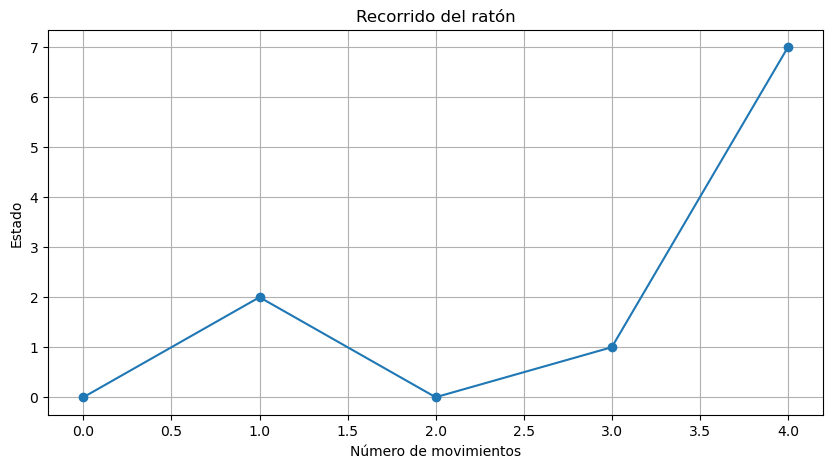

In [23]:
# Graficando:

plt.figure(figsize=(10,5))

plt.plot(
    range(len(historial)),
    historial,
    marker = "o"
)


plt.title("Recorrido del ratón")

plt.xlabel("Número de movimientos")
plt.ylabel("Estado")

plt.grid()

plt.show()

La gráfica nos muestra cómo cambia la posición del ratón conforme avanza el tiempo.

Tenemos que el proceso termina cuando el ratón alcanza:

- la comida, estado 7 (como en este caso)
- o la descarga eléctrica, estado 8

Usaremos el método de Monte Carlo para repetir nuestro procesos más veces:

In [24]:
def raton():
    
    estado = 0

    # El proceso continúa hasta llegar a uno de los estados absorbentes

    while True:

        # El ratón encontró comida
        if estado == 7:
            return 1

        # El ratón recibió descarga
        if estado == 8:
            return 0

        # Elegimos movimiento aleatorio

        estado = random.choice(conexiones[estado])

La función anterior devuelve:

- 1 si el ratón alcanza la comida
- 0 si llega a la descarga eléctrica

In [25]:
# Número de simulaciones

N = 10000

# Lista para guardar resultados

resultados = []

# Ejecutamos simulaciones

for i in range(N):

    resultado = raton()

    resultados.append(resultado)

probabilidad = np.mean(resultados)

print(f"Probabilidad aproximada de llegar a la comida: {probabilidad:.4f}")

Probabilidad aproximada de llegar a la comida: 0.5084


El promedio que obtuvimos representa la proba aproximada de que el ratón alcance la comida comenzando desde el estado 0.

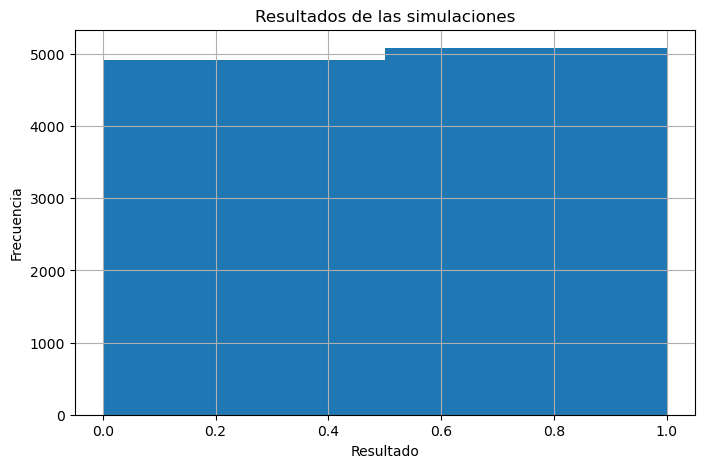

In [26]:
# Histograma:

plt.figure(figsize=(8,5))

plt.hist(
    resultados,
    bins = 2
)

plt.title("Resultados de las simulaciones")

plt.xlabel("Resultado")
plt.ylabel("Frecuencia")

plt.grid()

plt.show()

Observamos que las 2 posibilidades ocurren con frecuencias similares por lo que ninguna domina.

Sea  $P_i$ la probabilidad de que el ratón llegue a la comida comenzando desde el estado $i$

Los estados absorbentes son $P_7 = 1$ ,ya que si el ratón llega a la comida, el proceso termina exitosamente.

Y $P_8 = 0$ ,porque si el ratón llega a la descarga eléctrica pues fracasa.
    
Para cualquier otro estado: $P_i = \sum_j p_{ij}P_j$

donde:

- $p_{ij}$ representa la probabilidad de transición,
- y $P_j$ representa la probabilidad de éxito desde el siguiente estado.

Por ejemplo, para el estado 0: $P_0 = \frac{1}{2}(P_1 + P_2)$

Tenemos la probabilidad $\frac{1}{2}$ porque desde la casilla 0 existen únicamente dos movimientos posibles y ambos son igual de probables.

Para el estado 1: $P_1 = \frac{1}{3}(P_0 + P_3 + 1)$

La probabilidad $\frac{1}{3}$ aparece porque existen tres movimientos posibles: regresar a 0, avanzar a 3 o llegar directamente a la comida.

#### Conclusiones

El problema lo podemos modelar con una cadena de Markov ya que el siguiente movimiento depende únicamente de la posición actual del ratón.

La simulación Monte Carlo nos permitió aproximar la probabilidad de alcanzar la comida.